<a href="https://colab.research.google.com/github/jyotish89/MLperovskite/blob/main/MLperov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip -q perovskite_bandgap_pipeline.zip
%cd project

/content/project


In [ ]:
!pip install -r requirements.txt -q

In [ ]:
!python scripts/run_validation.py

Cleaned rows: 10060 (see results/tables/cleaning_report.md)


In [ ]:
!python scripts/run_tuning.py

{
  "base": {
    "best_params": {
      "min_samples_leaf": 10,
      "max_leaf_nodes": 63,
      "max_iter": 150,
      "max_depth": 12,
      "learning_rate": 0.08,
      "l2_regularization": 0.01
    },
    "best_cv_score_neg_mae": -0.4290936667955673
  },
  "quantile_lower": {
    "quantile": 0.025,
    "best_params": {
      "min_samples_leaf": 20,
      "max_leaf_nodes": 31,
      "max_iter": 500,
      "max_depth": 5,
      "learning_rate": 0.15,
      "l2_regularization": 0.0
    },
    "best_cv_score_neg_pinball": -0.017601066542349292
  },
  "quantile_upper": {
    "quantile": 0.975,
    "best_params": {
      "min_samples_leaf": 10,
      "max_leaf_nodes": 31,
      "max_iter": 500,
      "max_depth": 3,
      "learning_rate": 0.05,
      "l2_regularization": 0.01
    },
    "best_cv_score_neg_pinball": -0.05858778558515062
  },
  "cv_scheme": "GroupKFold(n_splits=5) grouped by formula",
  "random_search_n_iter": 40,
  "tuning_seed": 42,
  "dependency_versions": {
    "pyth

In [ ]:
!python scripts/run_repeated_benchmark.py

               method  n_seeds  coverage_mean  coverage_boot_lo  coverage_boot_hi  width_mean  width_boot_lo  width_boot_hi
0    global_conformal       20       0.962915          0.956190          0.968933    3.776897       3.728333       3.818582
1                 gpr       20       0.890426          0.882556          0.898240    3.472635       3.464397       3.480064
2  mondrian_conformal       20       0.957934          0.949617          0.966019    3.892756       3.802316       3.984181
3         quantile_gb       20       0.503679          0.492046          0.515063    3.759122       3.740597       3.779171


In [ ]:
!python scripts/run_lobo.py

  site_type  n_held_out_values  n_records  coverage_mean  coverage_boot_lo  coverage_boot_hi  width_mean  width_boot_lo  width_boot_hi
0    A_site                 17         85       0.973622          0.963535          0.982749    3.728897       3.697158       3.758730
1    B_site                 54        270       0.969423          0.956680          0.981044    3.733150       3.715317       3.750567
2    X_site                 10         50       0.905475          0.866099          0.940333    3.713519       3.674145       3.751287
{'quartile_agreement_rate': 0.2315151515151515, 'spearman_corr': 0.07253826586806522}


In [ ]:
!python scripts/run_sensitivity.py

   mondrian_min_group_threshold  coverage_mean  coverage_boot_lo  coverage_boot_hi  width_mean  width_boot_lo  width_boot_hi  mean_n_groups_below_threshold  feasible
0                             5       0.942955          0.933996          0.951440    3.774592       3.685539       3.862389                         108.05      True
1                            10       0.957934          0.949617          0.966019    3.892756       3.802316       3.984181                         123.35      True
2                            15       0.958296          0.949883          0.966535    3.897373       3.806502       3.989126                         123.95      True
3                            20       0.958298          0.950010          0.966523    3.877579       3.794819       3.963497                         124.20      True
   gpr_training_rows_requested  gpr_training_rows_used  feasible  coverage  coverage_wilson_lo  coverage_wilson_hi  mean_width  mean_predictive_std
0                     

In [ ]:
!python scripts/build_report.py

Tables written to /content/project/results/tables and /content/project/results/latex
All figures saved to /content/project/results/figures
Manuscript written to /content/project/results/markdown/manuscript_summary.md and /content/project/results/latex/manuscript_summary.tex
Done. See results/figures, results/tables, results/markdown, results/latex.


In [ ]:
!zip -r results_and_checkpoints.zip results data/checkpoints
from google.colab import files
files.download("results_and_checkpoints.zip")

  adding: results/ (stored 0%)
  adding: results/tables/ (stored 0%)
  adding: results/tables/sensitivity_gpr_ladder.csv (deflated 47%)
  adding: results/tables/novelty_mahalanobis.csv (deflated 53%)
  adding: results/tables/novelty_euclidean.csv (deflated 49%)
  adding: results/tables/cleaning_report.md (deflated 53%)
  adding: results/tables/dataset_table.md (deflated 61%)
  adding: results/tables/lobo_aggregate.csv (deflated 43%)
  adding: results/tables/model_table.md (deflated 64%)
  adding: results/tables/main_benchmark_aggregate.csv (deflated 45%)
  adding: results/tables/benchmark_table.md (deflated 66%)
  adding: results/tables/lobo_table.md (deflated 67%)
  adding: results/tables/sensitivity_mondrian_threshold.csv (deflated 46%)
  adding: results/latex/ (stored 0%)
  adding: results/latex/lobo_table.tex (deflated 45%)
  adding: results/latex/benchmark_table.tex (deflated 47%)
  adding: results/latex/manuscript_summary.tex (deflated 51%)
  adding: results/latex/dataset_table.t

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%cd /content/project
import sys
sys.path.insert(0, 'src')

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import config as cfg

/content/project


In [ ]:
row_level    = pd.read_csv(cfg.CACHE_DIR / "main_benchmark_row_level.csv")
per_seed_df  = pd.read_csv(cfg.CACHE_DIR / "main_benchmark_per_seed.csv")
lobo_agg     = pd.read_csv(cfg.TAB_DIR / "lobo_aggregate.csv")
euclid_summary = pd.read_csv(cfg.TAB_DIR / "novelty_euclidean.csv")
mahal_summary  = pd.read_csv(cfg.TAB_DIR / "novelty_mahalanobis.csv")

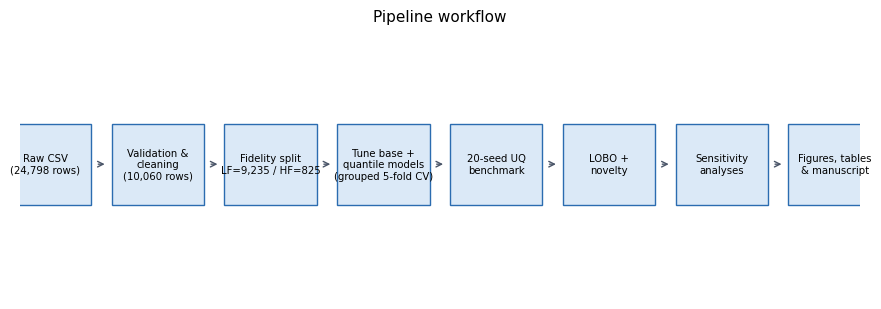

In [ ]:
steps = [
    "Raw CSV\n(24,798 rows)", "Validation &\ncleaning\n(10,060 rows)",
    "Fidelity split\nLF=9,235 / HF=825", "Tune base +\nquantile models\n(grouped 5-fold CV)",
    "20-seed UQ\nbenchmark", "LOBO +\nnovelty", "Sensitivity\nanalyses", "Figures, tables\n& manuscript",
]
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis("off")
n = len(steps)
xs = np.linspace(0.03, 0.97, n)
for i, (x, s) in enumerate(zip(xs, steps)):
    ax.add_patch(plt.Rectangle((x - 0.055, 0.35), 0.11, 0.3, fill=True,
                                facecolor="#dbe9f7", edgecolor="#2b6cb0", zorder=2))
    ax.text(x, 0.5, s, ha="center", va="center", fontsize=7.3, zorder=3)
    if i < n - 1:
        ax.annotate("", xy=(xs[i + 1] - 0.06, 0.5), xytext=(x + 0.06, 0.5),
                    arrowprops=dict(arrowstyle="->", color="#4a5568"))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Pipeline workflow", fontsize=11)
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "workflow_diagram.png")
plt.show()

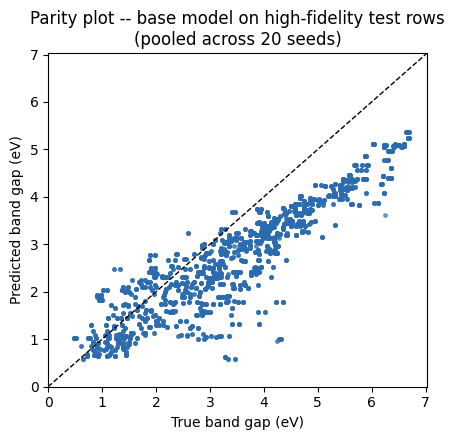

In [ ]:
sub = row_level[row_level["method"] == "global_conformal"]
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(sub["y_true"], sub["point_pred"], s=6, alpha=0.25, color="#2b6cb0")
lims = [0, max(sub["y_true"].max(), sub["point_pred"].max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("True band gap (eV)"); ax.set_ylabel("Predicted band gap (eV)")
ax.set_title("Parity plot -- base model on high-fidelity test rows\n(pooled across 20 seeds)")
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "parity_plot.png")
plt.show()

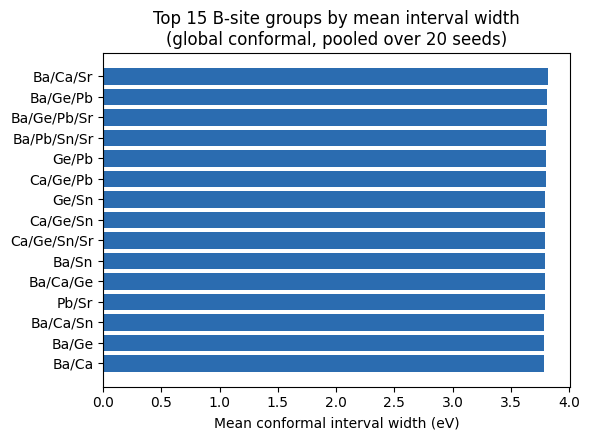

In [ ]:
top_n = 15
grp = sub.groupby("B_site")["width"].mean().sort_values(ascending=False).head(top_n)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(grp.index[::-1], grp.values[::-1], color="#2b6cb0")
ax.set_xlabel("Mean conformal interval width (eV)")
ax.set_title(f"Top {top_n} B-site groups by mean interval width\n(global conformal, pooled over 20 seeds)")
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "per_site_widths.png")
plt.show()

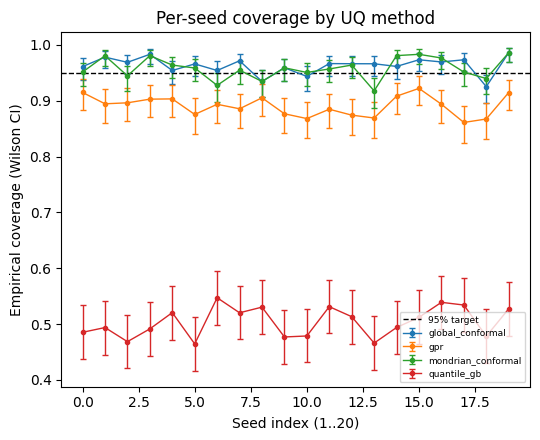

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for m in per_seed_df["method"].unique():
    s = per_seed_df[per_seed_df["method"] == m].sort_values("seed")
    ax.errorbar(
        range(len(s)), s["coverage"],
        yerr=[s["coverage"] - s["coverage_wilson_lo"], s["coverage_wilson_hi"] - s["coverage"]],
        marker="o", ms=3, lw=1, capsize=2, label=m,
    )
ax.axhline(1 - cfg.ALPHA, color="k", ls="--", lw=1, label=f"{int((1-cfg.ALPHA)*100)}% target")
ax.set_xlabel("Seed index (1..20)"); ax.set_ylabel("Empirical coverage (Wilson CI)")
ax.set_title("Per-seed coverage by UQ method")
ax.legend(fontsize=6.5, loc="lower right")
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "calibration_curve.png")
plt.show()

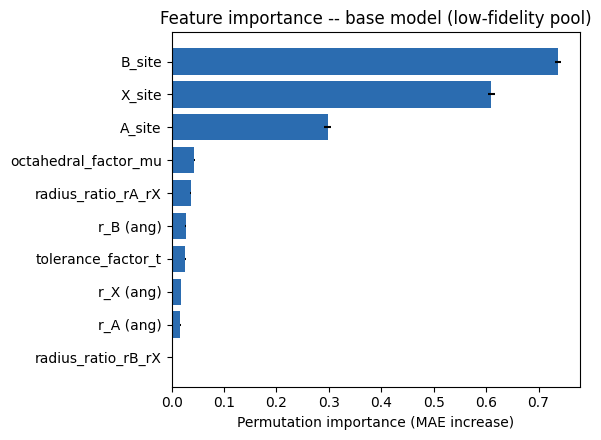

In [ ]:
import preprocessing as pp
import models as mdl
import data_validation as dv
import fidelity as fid
from sklearn.inspection import permutation_importance

df_clean, _ = dv.run(save=False)
lf, hf = fid.split(df_clean)
lf_m = pp.to_model_frame(lf)
tuned = mdl.load_tuned_config()
base = mdl.build_base_model(tuned)
X, y = pp.X_y(lf_m)
base.fit(X, y)
result = permutation_importance(base, X, y, n_repeats=5, random_state=0, n_jobs=1)
order = np.argsort(result.importances_mean)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(np.array(cfg.FEATURES)[order], result.importances_mean[order],
        xerr=result.importances_std[order], color="#2b6cb0")
ax.set_xlabel("Permutation importance (MAE increase)")
ax.set_title("Feature importance -- base model (low-fidelity pool)")
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "feature_importance.png")
plt.show()

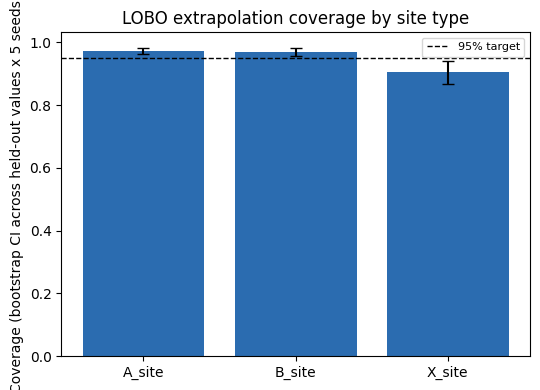

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4))
x = np.arange(len(lobo_agg))
ax.bar(x, lobo_agg["coverage_mean"],
       yerr=[lobo_agg["coverage_mean"] - lobo_agg["coverage_boot_lo"],
             lobo_agg["coverage_boot_hi"] - lobo_agg["coverage_mean"]],
       capsize=4, color="#2b6cb0")
ax.axhline(1 - cfg.ALPHA, color="k", ls="--", lw=1, label=f"{int((1-cfg.ALPHA)*100)}% target")
ax.set_xticks(x); ax.set_xticklabels(lobo_agg["site_type"])
ax.set_ylabel("Coverage (bootstrap CI across held-out values x 5 seeds)")
ax.set_title("LOBO extrapolation coverage by site type")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "lobo_coverage.png")
plt.show()

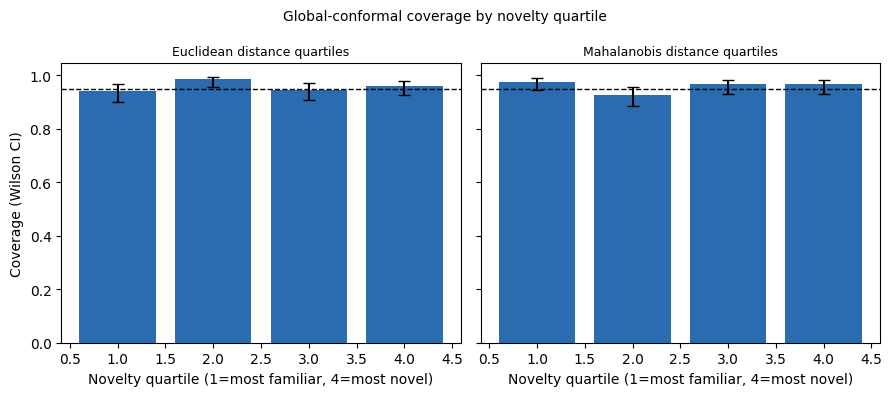

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, summary, title in zip(axes, [euclid_summary, mahal_summary],
                               ["Euclidean distance quartiles", "Mahalanobis distance quartiles"]):
    ax.bar(summary["quartile"], summary["coverage"],
           yerr=[summary["coverage"] - summary["coverage_wilson_lo"],
                 summary["coverage_wilson_hi"] - summary["coverage"]],
           capsize=4, color="#2b6cb0")
    ax.axhline(1 - cfg.ALPHA, color="k", ls="--", lw=1)
    ax.set_xlabel("Novelty quartile (1=most familiar, 4=most novel)")
    ax.set_title(title, fontsize=9)
axes[0].set_ylabel("Coverage (Wilson CI)")
fig.suptitle("Global-conformal coverage by novelty quartile", fontsize=10)
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "novelty_binned.png")
plt.show()